In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Ammonia synthesis at high pressure (Illustration 13.1-8, Figures 13.1-5 and 13.1-6)

Nitrogen fixation,

$$\tfrac12\mathrm{N_2}+\tfrac32\mathrm{H_2}\;\rightleftharpoons\;\mathrm{NH_3}$$

is exothermic, so its equilibrium constant falls as the temperature rises. Commercial
reactors run hot anyway, because the rate is what limits them, and they recover the lost
conversion with pressure: $\Delta\nu=-1$, so squeezing the mixture pushes the reaction
forward. Operating conditions are roughly 350 bar and 350 to 600 °C.

Two things make this more than a substitution. First, $K_a$ has to be carried from 25 °C
to 500-800 K through the heat-capacity polynomial, not by assuming a constant heat of
reaction. Second, at these pressures the gas is nowhere near ideal, so the fugacity
coefficient ratio

$$K_\nu=\prod_i\bar\phi_i^{\,\nu_i}$$

cannot be set to one -- and because $\bar\phi_i$ depends on composition, and composition
depends on the extent of reaction, the solve is a fixed point rather than a formula.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.reaction import Reaction, equilibrium_extent, K_nu_from_eos
from thermo.pr_mixture import PRMixture
from thermo.peng_robinson import PengRobinson
from thermo.charts import use_book_style

use_book_style()

ammonia = Reaction.parse("0.5 N2 + 1.5 H2 = NH3").check_balance()
FEED = {"N2": 0.5, "H2": 1.5}            # stoichiometric, as in Illustration 13.1-4
ORDER = ["N2", "H2", "NH3"]

# NAME HYDROGEN IN FULL. `pure_property.csv` distinguishes normal hydrogen from the
# equilibrium ortho/para mixture, and the bare word "hydrogen" is also a substring of
# hydrogen bromide, chloride, cyanide, sulfide and the halides -- so an abbreviated key
# is an invitation to compute the wrong reaction and never find out. The assertion below
# is cheap and it is the only thing standing between this notebook and that mistake.
MIX = PRMixture([PengRobinson.from_database(n)
                 for n in ("nitrogen", "hydrogen (normal)", "ammonia")])
assert [c.name for c in MIX.components] == ["nitrogen", "hydrogen (normal)", "ammonia"]

print(f"reaction: {ammonia.equation}      dnu = {ammonia.delta_nu:g}")
print("EOS components, in the order K_nu reads them: "
      + ", ".join(f"{s} = {c.name}" for s, c in zip(ORDER, MIX.components)))

reaction: 0.5 N2 + 1.5 H2 = NH3      dnu = -1
EOS components, in the order K_nu reads them: N2 = nitrogen, H2 = hydrogen (normal), NH3 = ammonia


## The equilibrium constant over the reactor's temperature range

$\Delta_{rxn}G^\circ$ at 25 °C comes from Appendix A.IV and is carried to $T$ with the
heat-capacity polynomial of Appendix A.II, which is Eq. 13.1-23b. Nothing about the gas
phase enters yet: $K_a$ is a property of the reaction and the temperature alone.

The value at 450 K is carried along as a fixed point of this notebook. It is not needed
for the figures; it is there so that a change in the appendix data, or in how the
polynomial is integrated, fails the run instead of quietly moving every curve below.

In [3]:
TEMPS = [500, 600, 700, 800]
Ka = {T: float(ammonia.Ka(T)) for T in TEMPS}

table = pd.DataFrame({"T (K)": TEMPS, "Ka": [Ka[T] for T in TEMPS]})
print(table.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

print(f"\nregression pin:  Ka(450 K) = {float(ammonia.Ka(450.0)):.4f}")
assert abs(float(ammonia.Ka(450.0)) - 1.2176) < 5e-4

 T (K)       Ka
   500   0.3241
   600  0.04247
   700 0.009554
   800 0.003044

regression pin:  Ka(450 K) = 1.2176


## Solving for the extent of reaction

$K_\nu$ is evaluated from the Peng-Robinson equation of state at the equilibrium
composition, so it has to be iterated with the extent. The iteration is damped because the
map stiffens above about 300 bar.

In [4]:
def extent(T, P, ideal=False, tol=1e-10):
    """Equilibrium extent at T and P, iterating K_nu unless ideal is asked for."""
    K_nu, state = 1.0, None
    for _ in range(200):
        state = equilibrium_extent(ammonia, T, FEED, P=P, Ka=Ka[T], K_nu=K_nu)
        if ideal:
            return state.X, 1.0
        new = float(K_nu_from_eos(ammonia, T, P, state.y, MIX, ORDER))
        if abs(new - K_nu) < tol:
            break
        K_nu = 0.7 * K_nu + 0.3 * new
    return state.X, K_nu


P_GRID = np.linspace(1.0, 1000.0, 200)
X, KNU, X_IDEAL = {}, {}, {}
for T in TEMPS:
    X[T], KNU[T] = map(np.array, zip(*(extent(T, P) for P in P_GRID)))
    X_IDEAL[T] = np.array([extent(T, P, ideal=True)[0] for P in P_GRID])
print("solved", len(TEMPS), "isotherms over 1 to 1000 bar")

solved 4 isotherms over 1 to 1000 bar


## Figure 13.1-5 -- the fugacity coefficient ratio

$K_\nu$ leaves unity almost immediately and then falls a long way: by 1000 bar it is 0.61
at 800 K and 0.045 at 500 K. It falls furthest at the lowest temperature, where the
mixture is both closest to its critical region and almost entirely ammonia, the one
strongly nonideal species of the three.

Two decades of range is why this panel is drawn on a logarithmic $K_\nu$ axis. On a linear
one the three upper isotherms crowd into the top fifth of the frame and the 500 K curve
lies on the axis.

Every curve is labeled on itself rather than in a legend, so the figure can be read
without moving the eye off it -- and so that nothing depends on the order of a legend.

Figure 13.1-5: no label collisions


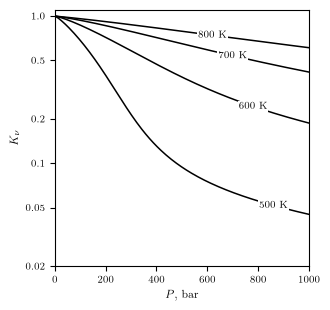

In [5]:
import matplotlib.text as mtext


def renderer(fig):
    """`get_renderer` lives on the Agg canvas, not on the bare FigureCanvasBase that a
    headless kernel may hand you -- so a gate that passes in JupyterLab can die in the
    batch re-execution, which is exactly where it has to work."""
    try:
        return fig.canvas.get_renderer()
    except AttributeError:
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        canvas = FigureCanvasAgg(fig)
        canvas.draw()
        return canvas.get_renderer()


def label_curve(ax, line, at, text, side="on", size=7):
    """Write `text` for `line` at pressure `at`, and remember which curve it belongs to.

    `side` is 'on' (the label sits on its own curve, masked by a white box -- the
    book's own device on every property chart), 'up' or 'dn'. The offset is
    multiplicative on a log axis and additive on a linear one, which is the only sane
    reading of "nudge it clear" in each case.
    """
    x, y = line.get_xydata().T
    yc = float(np.interp(at, x, y))
    if ax.get_yscale() == "log":
        yc *= {"on": 1.0, "up": 1.30, "dn": 1 / 1.30}[side]
    else:
        yc += {"on": 0.0, "up": 0.050, "dn": -0.050}[side]
    t = ax.text(at, yc, text, fontsize=size, ha="center", va="center", zorder=6,
                bbox=dict(fc="white", ec="none", pad=0.6) if side == "on" else None)
    OWNER[t.get_text()] = line
    return t


def collisions(ax):
    """Labels must not overlap each other, and must not sit on a curve that is not
    theirs. A label on its OWN curve is intentional: the white box is what makes it
    legible, and that is the one case this gate has to let through."""
    ax.figure.canvas.draw()
    rend = renderer(ax.figure)
    boxes = [(t.get_text(), mtext.Text.get_window_extent(t, renderer=rend))
             for t in ax.texts if (t.get_text() or "").strip()]
    bad = [f"{p} / {q}" for i, (p, bp) in enumerate(boxes)
           for q, bq in boxes[i + 1:] if bp.overlaps(bq)]
    for name, box in boxes:
        pad = box.expanded(1.10, 1.30)
        for line in ax.lines:
            if line is OWNER.get(name):
                continue
            xy = ax.transData.transform(line.get_xydata())
            if any(pad.contains(px, py) for px, py in xy):
                bad.append(f"{name} sits on a curve that is not its own")
                break
    return sorted(set(bad))


# The label pressures are a cascade down the family -- 620, 700, 780, 860 bar for 800,
# 700, 600, 500 K -- so that four labels of the same width never share a column.
KNU_LABEL_AT = {800: 620, 700: 700, 600: 780, 500: 860}

OWNER = {}
fig5, ax = plt.subplots(figsize=(3.4, 3.2))
for T in TEMPS:
    (line,) = ax.plot(P_GRID, KNU[T], "-", color="k", lw=1.1)
    label_curve(ax, line, KNU_LABEL_AT[T], f"{T} K")

ax.set_yscale("log")
ax.set_xlim(0, 1000)
ax.set_ylim(0.02, 1.1)
ax.set_xticks(np.arange(0, 1001, 200))
ax.set_yticks([0.02, 0.05, 0.1, 0.2, 0.5, 1.0])
ax.set_yticklabels(["0.02", "0.05", "0.1", "0.2", "0.5", "1.0"])
ax.tick_params(labelsize=7)
ax.tick_params(axis="y", which="minor", left=False)
ax.set_xlabel(r"$P$, bar", fontsize=8)
ax.set_ylabel(r"$K_\nu$", fontsize=8)
fig5.tight_layout()

bad = collisions(ax)
print(f"Figure 13.1-5: {'; '.join(bad) if bad else 'no label collisions'}")
assert not bad, "move a label before staging this art"
plt.show()

## Figure 13.1-6 -- the equilibrium extent of reaction

The ideal-gas result -- the same calculation with $K_\nu$ held at one -- is drawn at 500
and 800 K, and it is drawn dotted and labeled *ideal* on the figure itself, so that the
figure says which curve is which without help from the caption.

The two pairs behave quite differently. At 800 K
nonideality is worth 15 % in the conversion at 1000 bar, and the gap is still opening. At
500 K it is worth 4 % at the same pressure -- not because the gas is more nearly ideal
there (Figure 13.1-5 says the opposite, emphatically) but because the reaction has already
gone nearly to completion, and there is almost nothing left for a correction to move.
**A large correction to $K_\nu$ does not have to mean a large correction to anything you
would measure.**

Figure 13.1-6: no label collisions


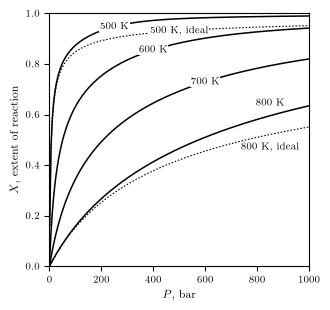

In [6]:
# Where each label goes. The two 500 K curves are within 0.05 of each other everywhere
# and both are pressed against X = 1, so they cannot be labeled in the same column: the
# real one is named at 250 bar and the ideal one at 500 bar, where the channel between the
# ideal curve and the 600 K curve is widest. The 800 K pair is far enough apart to take
# both labels at 850 bar, one above its curve and one below.
X_LABEL_AT = {500: 250, 600: 400, 700: 600, 800: 850}
IDEAL_LABEL_AT = {500: (500, "on"), 800: (850, "dn")}

OWNER = {}
fig6, ax = plt.subplots(figsize=(3.4, 3.2))
for T in TEMPS:
    (line,) = ax.plot(P_GRID, X[T], "-", color="k", lw=1.1)
    label_curve(ax, line, X_LABEL_AT[T], f"{T} K", "up" if T == 800 else "on")
for T, (at, side) in IDEAL_LABEL_AT.items():
    (line,) = ax.plot(P_GRID, X_IDEAL[T], color="k", lw=0.8, dashes=(1.4, 1.6))
    label_curve(ax, line, at, f"{T} K, ideal", side)

ax.set_xlim(0, 1000)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(0, 1001, 200))
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.tick_params(labelsize=7)
ax.set_xlabel(r"$P$, bar", fontsize=8)
ax.set_ylabel(r"$X$, extent of reaction", fontsize=8)
fig6.tight_layout()

bad = collisions(ax)
print(f"Figure 13.1-6: {'; '.join(bad) if bad else 'no label collisions'}")
assert not bad, "move a label before staging this art"
plt.show()

## What the figures say

Five observations, each checked here rather than asserted, so that a later change to the
data or the equation of state cannot quietly invalidate the text beside the figures.

In [7]:
checks = []
checks.append(("extent rises with pressure at every temperature",
               all(np.all(np.diff(X[T]) > 0) for T in TEMPS)))
checks.append(("extent falls with temperature at every pressure",
               bool(np.all(np.diff(np.array([X[T] for T in TEMPS]), axis=0) < 0))))
checks.append((f"K_nu falls well below unity at high pressure, furthest at low "
               f"temperature ({KNU[500][-1]:.3f} at 500 K vs {KNU[800][-1]:.3f} at "
               f"800 K, 1000 bar)",
               KNU[500][-1] < KNU[800][-1] < 1.0 and KNU[500][-1] < 0.1))
gap = max(abs(X[T][-1] / X_IDEAL[T][-1] - 1) for T in TEMPS if T in X_IDEAL)
checks.append((f"nonideality changes the conversion by up to {100*gap:.0f} percent at "
               f"1000 bar",
               gap > 0.05))
# The two 500 K curves stay close and the two 800 K curves separate -- the point the
# figure is drawn to make, and the reason the ideal-gas result is shown at both ends of
# the range rather than at one.
near, far = (X[500][-1] / X_IDEAL[500][-1] - 1), (X[800][-1] / X_IDEAL[800][-1] - 1)
checks.append((f"nonideality matters more where conversion is low: {100*far:.0f} percent "
               f"at 800 K against {100*near:.0f} percent at 500 K, both at 1000 bar",
               far > 3 * near))
for text, ok in checks:
    print(f"{'holds ' if ok else 'FAILS '}  {text}")
assert all(ok for _, ok in checks)

print("\nAt 350 bar, the middle of the commercial range:")
i = int(np.argmin(abs(P_GRID - 350.0)))
for T in TEMPS:
    print(f"  {T} K:  X = {X[T][i]:.4f}   K_nu = {KNU[T][i]:.3f}")

holds   extent rises with pressure at every temperature
holds   extent falls with temperature at every pressure
holds   K_nu falls well below unity at high pressure, furthest at low temperature (0.045 at 500 K vs 0.610 at 800 K, 1000 bar)
holds   nonideality changes the conversion by up to 15 percent at 1000 bar
holds   nonideality matters more where conversion is low: 15 percent at 800 K against 4 percent at 500 K, both at 1000 bar

At 350 bar, the middle of the commercial range:
  500 K:  X = 0.9670   K_nu = 0.162
  600 K:  X = 0.8385   K_nu = 0.521
  700 K:  X = 0.6178   K_nu = 0.748
  800 K:  X = 0.3842   K_nu = 0.851


## Staging the art

Both panels are drawn at the size they are printed at -- 3.4 in wide, one column -- so
that 7 pt in the notebook is 7 pt on the page and nothing is scaled after the fact.

    pdf/Figure_13.1-5.pdf   ->   deliverables/figures/print-bw/ch13/c13f005.pdf
    pdf/Figure_13.1-6.pdf   ->   deliverables/figures/print-bw/ch13/c13f006.pdf

In [8]:
os.makedirs("pdf", exist_ok=True)
for fig, name in ((fig5, "Figure_13.1-5"), (fig6, "Figure_13.1-6")):
    path = f"pdf/{name}.pdf"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  wrote {path}")

# A figure that came out in DejaVu Sans has not been set for the book. `use_book_style`
# reports which of the two typographies it got, and both are Computer Modern.
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.1-5.pdf


  wrote pdf/Figure_13.1-6.pdf

  typography: LaTeX Computer Modern


## Your turn

1. At 1000 bar $K_\nu$ is **0.045** at 500 K and **0.610** at 800 K -- a factor of 14
   between them -- and yet nonideality is worth only 4 % in the conversion at 500 K
   against 15 % at 800 K. **The larger correction produces the smaller effect.** Resolve
   that, then prove the exact statement behind it: with $\Delta\nu=-1$ the equilibrium
   relation is $K_a=K_yK_\nu P^{-1}$, so the composition can depend on $P$ and $K_\nu$
   only through the ratio $P/K_\nu$. Check it numerically -- solve the *ideal-gas* problem
   at $P/K_\nu$ and see whether you get the equation-of-state answer at $P$. Then say what
   the effective pressure is at 500 K and 1000 bar, and why no reactor can exploit it.
2. Real synthesis gas is not clean: it carries argon and methane that neither react nor
   can be economically removed. Add 5 mol % inert to `FEED` and recompute Figure 13.1-6.
   Which costs more conversion at 350 bar -- the 5 % inert, or 50 K of extra temperature?
   The answer decides whether a plant spends its money on purification or on cooling.
3. `PRMixture` is built here with **no binary interaction parameters**, so every $k_{ij}$
   is zero. Give the N$_2$-H$_2$ and NH$_3$-H$_2$ pairs a $k_{ij}$ of $\pm0.1$ and redraw
   Figure 13.1-5. Does the figure move by more or less than changing $K_a$ moved it? A
   model's *un-fitted* parameters are part of its uncertainty, and this is how you find
   out how large that part is.
4. `K_nu_from_eos` refuses to infer which equation-of-state component is which species --
   it makes the caller state the order, and the cell above asserts the names it got. Find
   out why by breaking it deliberately: pass `ORDER` permuted, and compare the $K_\nu$ you
   get against the right answer at 500 K and 350 bar. **Every permutation converges, and
   every one returns a number you would not question.** What kind of mistake can a
   calculation of this shape never catch by itself, and what would you have to bring in
   from outside to catch it?
5. The iteration on $K_\nu$ is damped -- `0.7 * K_nu + 0.3 * new`. Replace it with pure
   successive substitution and find the pressure at which it stops converging at 500 K.
   Then account for the stiffness physically: what is it about $\Delta\nu=-1$ and a
   mixture that becomes 93 % ammonia that makes $K_\nu$ and the extent chase each other?
6. Section 13.1 gives the commercial range as roughly 350 bar and 350 to 600 °C, but these
   figures stop at 800 K -- below the top of that range. Extend them to 900 K and read the
   conversion at 350 bar. Given how little of the feed converts there, work out what a
   plant must do with the remainder, and why a reactor is run at a temperature the
   equilibrium plainly dislikes.